In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 16
dataset_path = '/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Datasets/Datasets/module2'
classes = ['clear', 'restorable', 'unrestorable']

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42,
    classes=classes
)

validation_generator = val_datagen.flow_from_directory(
    dataset_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42,
    classes=classes
)

print(f"Class indices: {train_generator.class_indices}")
print(f"Training samples: {train_generator.samples}")
print(f"Validation samples: {validation_generator.samples}")

Found 1920 images belonging to 3 classes.
Found 480 images belonging to 3 classes.
Class indices: {'clear': 0, 'restorable': 1, 'unrestorable': 2}
Training samples: 1920
Validation samples: 480


In [ ]:
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

Class weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0)}


In [ ]:
def build_model(num_classes=3):
    base_model = MobileNetV3Small(
        weights='imagenet',
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    x = BatchNormalization()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    return model, base_model

model, base_model = build_model()

In [ ]:
callbacks = [
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        '/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_2/Models/best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history1 = model.fit(
    train_generator,
    epochs=30,
    validation_data=validation_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5936 - loss: 5.2919
Epoch 1: val_accuracy improved from -inf to 0.33333, saving model to /content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_2/Models/best_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.5942 - loss: 5.2852 - val_accuracy: 0.3333 - val_loss: 3.9398 - learning_rate: 0.0010
Epoch 2/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.7153 - loss: 3.1007
Epoch 2: val_accuracy improved from 0.33333 to 0.33958, saving model to /content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_2/Models/best_model.keras
120/120 ━━━━━━━━━━━━━━━━━━━━ 33s 279ms/step - accuracy: 0.7154 - loss: 3.0986 - val_accuracy: 0.3396 - val_loss: 2.9528 - learning_rate: 0.0010
Epoch 3/30
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.

In [ ]:
base_model.trainable = True
num_layers = len(base_model.layers)
freeze_until = int(num_layers * 0.7)

In [ ]:
for layer in base_model.layers[:freeze_until]:
    layer.trainable = False

print(f"Total layers: {num_layers}, Frozen: {freeze_until}, Trainable: {num_layers - freeze_until}")

Total layers: 157, Frozen: 109, Trainable: 48


## Fine tune Lower lr

In [ ]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history2 = model.fit(
    train_generator,
    epochs=20,
    validation_data=validation_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - accuracy: 0.3795 - loss: 2.0990
Epoch 1: val_accuracy did not improve from 0.84583
120/120 ━━━━━━━━━━━━━━━━━━━━ 60s 316ms/step - accuracy: 0.3803 - loss: 2.0958 - val_accuracy: 0.3417 - val_loss: 4.2956 - learning_rate: 1.0000e-05
Epoch 2/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - accuracy: 0.5962 - loss: 1.2942
Epoch 2: val_accuracy did not improve from 0.84583
120/120 ━━━━━━━━━━━━━━━━━━━━ 34s 284ms/step - accuracy: 0.5965 - loss: 1.2932 - val_accuracy: 0.3438 - val_loss: 5.1260 - learning_rate: 1.0000e-05
Epoch 3/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.7093 - loss: 0.9735
Epoch 3: val_accuracy did not improve from 0.84583
120/120 ━━━━━━━━━━━━━━━━━━━━ 34s 283ms/step - accuracy: 0.7094 - loss: 0.9731 - val_accuracy: 0.4604 - val_loss: 5.3572 - learning_rate: 1.0000e-05
Epoch 4/20
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 263ms/step - accuracy: 0.7500 - loss: 0.8406
Epoch 4: val_accuracy did not improve from 0.84583


## Full fine tune

In [ ]:
for layer in base_model.layers:
    layer.trainable = True

model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model.fit(
    train_generator,
    epochs=10,
    validation_data=validation_generator,
    callbacks=callbacks,
    class_weight=class_weight_dict
)

Epoch 1/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 259ms/step - accuracy: 0.3377 - loss: 2.7211
Epoch 1: val_accuracy did not improve from 0.84583
120/120 ━━━━━━━━━━━━━━━━━━━━ 85s 315ms/step - accuracy: 0.3376 - loss: 2.7211 - val_accuracy: 0.3333 - val_loss: 3.9057 - learning_rate: 1.0000e-06
Epoch 2/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.3476 - loss: 2.5325
Epoch 2: val_accuracy did not improve from 0.84583
120/120 ━━━━━━━━━━━━━━━━━━━━ 33s 276ms/step - accuracy: 0.3476 - loss: 2.5327 - val_accuracy: 0.4167 - val_loss: 3.4183 - learning_rate: 1.0000e-06
Epoch 3/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - accuracy: 0.3670 - loss: 2.3648
Epoch 3: val_accuracy did not improve from 0.84583
120/120 ━━━━━━━━━━━━━━━━━━━━ 33s 276ms/step - accuracy: 0.3670 - loss: 2.3648 - val_accuracy: 0.3333 - val_loss: 3.1977 - learning_rate: 1.0000e-06
Epoch 4/10
120/120 ━━━━━━━━━━━━━━━━━━━━ 0s 262ms/step - accuracy: 0.3658 - loss: 2.3166
Epoch 4: val_accuracy did not improve from 0.84583


In [ ]:
val_loss, val_acc = model.evaluate(validation_generator)
print(f'\nFinal Validation Accuracy: {val_acc * 100:.2f}%')

30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.2351 - loss: 2.8008

Final Validation Accuracy: 41.67%


In [ ]:
model.save('/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_2/Models/mobilenetv3_enhanced.keras')

## Eval

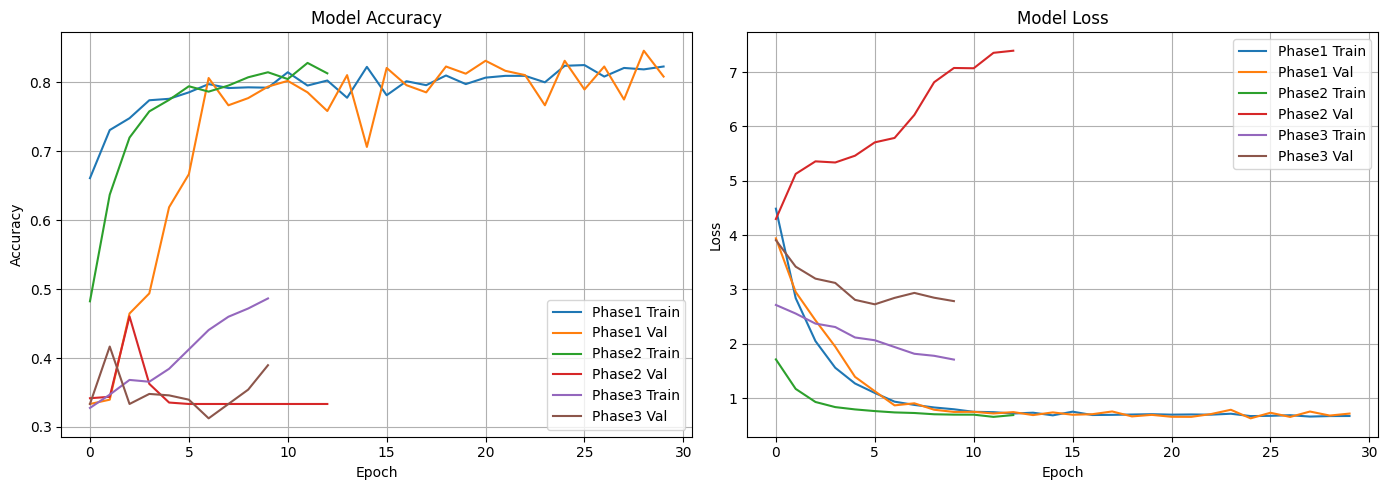

In [ ]:
def plot_history(histories, titles):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for hist, title in zip(histories, titles):
        axes[0].plot(hist.history['accuracy'], label=f'{title} Train')
        axes[0].plot(hist.history['val_accuracy'], label=f'{title} Val')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True)

    for hist, title in zip(histories, titles):
        axes[1].plot(hist.history['loss'], label=f'{title} Train')
        axes[1].plot(hist.history['val_loss'], label=f'{title} Val')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.show()

plot_history([history1, history2, history3], ['Phase1', 'Phase2', 'Phase3'])

# Test

In [ ]:
model = load_model('/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_2/Models/best_model.keras')

In [ ]:
IMG_SIZE = (224, 224)
classes = ['clear', 'restorable', 'unrestorable']
test_dir = "/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Datasets/Datasets/test"

In [ ]:
image_paths, ground_truths = [], []
for cls_name in classes:
    class_dir = os.path.join(test_dir, cls_name)
    if os.path.exists(class_dir):
        imgs = [os.path.join(class_dir, f) for f in os.listdir(class_dir)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        image_paths.extend(imgs)
        ground_truths.extend([cls_name] * len(imgs))
        print(f"Class '{cls_name}': {len(imgs)} test images")

print(f"Total test images: {len(image_paths)}")

Class 'clear': 50 test images
Class 'restorable': 50 test images
Class 'unrestorable': 50 test images
Total test images: 150


In [ ]:
def predict_batch(paths, batch_size=32):
    predictions, confidences = [], []
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_imgs = []
        for p in batch_paths:
            img = image.load_img(p, target_size=IMG_SIZE)
            img_array = image.img_to_array(img) / 255.0
            batch_imgs.append(img_array)
        batch_imgs = np.array(batch_imgs)
        preds = model.predict(batch_imgs, verbose=0)
        for pred in preds:
            pred_idx = np.argmax(pred)
            predictions.append(classes[pred_idx])
            confidences.append(pred[pred_idx])
    return predictions, confidences

predictions, confidences = predict_batch(image_paths)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(ground_truths, predictions, target_names=classes))

CLASSIFICATION REPORT
              precision    recall  f1-score   support

       clear       0.82      0.98      0.89        50
  restorable       0.96      0.88      0.92        50
unrestorable       0.91      0.80      0.85        50

    accuracy                           0.89       150
   macro avg       0.89      0.89      0.89       150
weighted avg       0.89      0.89      0.89       150



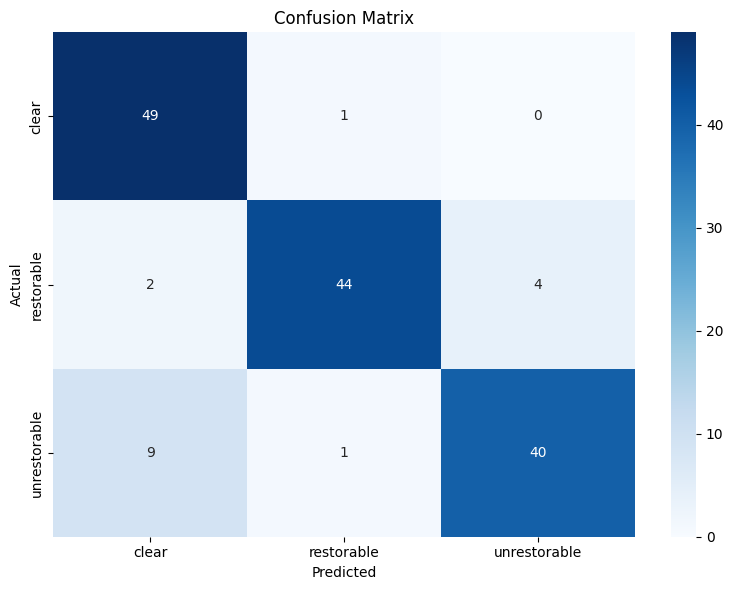

In [ ]:
cm = confusion_matrix(ground_truths, predictions, labels=classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [ ]:
print("\nPer-class Accuracy:")
for i, cls in enumerate(classes):
    cls_mask = np.array(ground_truths) == cls
    cls_acc = np.mean(np.array(predictions)[cls_mask] == cls)
    print(f"  {cls}: {cls_acc*100:.2f}%")


Per-class Accuracy:
  clear: 98.00%
  restorable: 88.00%
  unrestorable: 80.00%


In [ ]:
accuracy = np.mean(np.array(ground_truths) == np.array(predictions))
print(f"\nOverall Test Accuracy: {accuracy * 100:.2f}%")


Overall Test Accuracy: 88.67%


In [ ]:
df = pd.DataFrame({
    'Image_Path': image_paths,
    'Ground_Truth': ground_truths,
    'Prediction': predictions,
    'Confidence': confidences,
    'Correct': np.array(ground_truths) == np.array(predictions)
})
df.to_csv('/content/drive/MyDrive/Building-an-Adaptive-License-Plate-Recognition-and-Restoration-System-using-Multi-Task-Deep-Learning/Training/Module_2/test_predictions_detailed.csv', index=False)

In [ ]:
print("\nMisclassified Examples:")
misclassified = df[~df['Correct']].head(10)
print(misclassified[['Ground_Truth', 'Prediction', 'Confidence']])


Misclassified Examples:
     Ground_Truth    Prediction  Confidence
34          clear    restorable    0.685816
51     restorable  unrestorable    0.781230
65     restorable  unrestorable    0.525465
71     restorable         clear    0.853454
76     restorable  unrestorable    0.577182
78     restorable  unrestorable    0.555475
81     restorable         clear    0.649742
100  unrestorable         clear    0.825373
116  unrestorable         clear    0.556977
140  unrestorable         clear    0.960626
